# Laboratory Task 7 — Image Classification Using Pre-trained Models

This laboratory exercise evaluates and compares five pre-trained image classification models using a dataset of **150 images** divided into three classes: **Laptop, Mobile, and Supercar**. The models are evaluated using accuracy, precision, recall, F1-score, number of parameters, and inference time.

In [18]:
import os
import zipfile
import gc
import time
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from IPython.display import display, Markdown

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## Dataset Preparation

In [19]:
zip_candidates = [
    "image classification(1).zip",
    "/content/image classification(1).zip",
    "/mnt/data/image classification(1).zip"
]

zip_path = next((p for p in zip_candidates if os.path.exists(p)), None)

if zip_path is None:
    raise FileNotFoundError("Upload image classification(1).zip first.")

if not os.path.exists("images"):
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(".")

root = "images"

print(os.listdir(root))

['Supercars', 'Laptops', 'Moblies']


In [20]:
data_dict = {"X": [], "y": []}

classes = sorted([
    cls for cls in os.listdir(root)
    if os.path.isdir(os.path.join(root, cls))
])

class_to_num = {cls: i for i, cls in enumerate(classes)}

valid_ext = (".jpg", ".jpeg", ".png", ".jfif", ".webp")

for cls in classes:
    cls_path = os.path.join(root, cls)

    for img in sorted(os.listdir(cls_path)):
        if img.lower().endswith(valid_ext):
            data_dict["X"].append(os.path.join(cls_path, img))
            data_dict["y"].append(class_to_num[cls])

print("Classes:", classes)
print("Number of images:", len(data_dict["X"]))
print("Class mapping:", class_to_num)

Classes: ['Laptops', 'Moblies', 'Supercars']
Number of images: 150
Class mapping: {'Laptops': 0, 'Moblies': 1, 'Supercars': 2}


In [21]:
df = pd.DataFrame({
    "image_path": data_dict["X"],
    "label": data_dict["y"],
    "class_name": [classes[y] for y in data_dict["y"]]
})

df

,image_path,label,class_name
0,images/Laptops/02pPlSC851BxRP4BFdufSBJ-1.16055...,0,Laptops
1,images/Laptops/1200px-HP_2133_Mini-Note_PC_(fr...,0,Laptops
2,images/Laptops/1585819698956.jpg,0,Laptops
3,images/Laptops/1601533890-0994.jpg,0,Laptops
4,images/Laptops/1605478088_6c-acer.jpg,0,Laptops
...,...,...,...
145,images/Supercars/fastest-cars-world-2021-luxe-...,2,Supercars
146,images/Supercars/maxresdefault.jpg,2,Supercars
147,images/Supercars/mclaren-720s_0.jpg,2,Supercars
148,images/Supercars/mclaren-senna-gtr-01-15520526...,2,Supercars


## Custom Dataset

A custom PyTorch `Dataset` class is used to load each image, convert it to RGB format, apply the required model transformation, and return its corresponding class label.

In [22]:
class CustomDataset(Dataset):
    def __init__(self, data_dict, transform=None):
        self.data_dict = data_dict
        self.transform = transform

    def __len__(self):
        return len(self.data_dict["X"])

    def __getitem__(self, idx):
        image = Image.open(self.data_dict["X"][idx]).convert("RGB")
        label = self.data_dict["y"][idx]

        if self.transform:
            image = self.transform(image)

        return image, label

## Sample Image

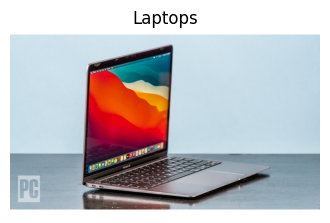

In [23]:
sample_index = 0
sample_image = Image.open(data_dict["X"][sample_index]).convert("RGB")

plt.figure(figsize=(4, 4))
plt.imshow(sample_image)
plt.title(classes[data_dict["y"][sample_index]].replace("_", " "))
plt.axis("off")
plt.show()

## Model Evaluation Setup

The dataset classes are matched with their corresponding ImageNet categories: **laptop**, **cellular telephone**, and **sports car**. Since the models are already pre-trained on ImageNet, no additional model training or fine-tuning is performed.

In [24]:
imagenet_name = {
    "Laptops": "laptop",
    "Moblies": "cellular telephone",
    "Supercars": "sports car"
}

display_name = {
    "Laptops": "Laptop",
    "Moblies": "Mobile",
    "Supercars": "Supercar"
}

results = []
all_predictions = {}

def save_result(result):
    global results
    results = [r for r in results if r["Model"] != result["Model"]]
    results.append(result)

def evaluate_model(model_name, model, dataloader, weights):
    model = model.to(device)
    model.eval()

    categories = weights.meta["categories"]

    target_indices = [
        categories.index(imagenet_name[cls])
        for cls in classes
    ]

    y_true = []
    y_pred = []

    start = time.time()

    with torch.inference_mode():
        for images, labels in dataloader:
            images = images.to(device)

            outputs = model(images)

            # Keep only the ImageNet outputs corresponding
            # to our three dataset classes
            outputs = outputs[:, target_indices]

            predictions = outputs.argmax(dim=1).cpu()

            y_true.extend(labels.numpy().tolist())
            y_pred.extend(predictions.numpy().tolist())

    elapsed = time.time() - start

    all_predictions[model_name] = pd.DataFrame({
        "Actual": [
            display_name[classes[i]]
            for i in y_true
        ],
        "Predicted": [
            display_name[classes[i]]
            for i in y_pred
        ]
    })

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "F1-score": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "Parameters (M)": sum(
            p.numel() for p in model.parameters()
        ) / 1_000_000,
        "Time (s)": elapsed
    }

## ResNet18

In [25]:
resnet18_weights = models.ResNet18_Weights.DEFAULT
resnet18_dataset = CustomDataset(data_dict, resnet18_weights.transforms())
resnet18_loader = DataLoader(resnet18_dataset, batch_size=8, shuffle=False)

resnet18_model = models.resnet18(weights=resnet18_weights)

resnet18_result = evaluate_model(
    "ResNet18",
    resnet18_model,
    resnet18_loader,
    resnet18_weights
)

save_result(resnet18_result)
display(pd.DataFrame(results).round(4))
display(all_predictions["ResNet18"].head(10))

del resnet18_model, resnet18_dataset, resnet18_loader
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


,Model,Accuracy,Precision,Recall,F1-score,Parameters (M),Time (s)
0,ResNet18,0.9133,0.9259,0.9133,0.9123,11.6895,4.2476


,Actual,Predicted
0,Laptop,Laptop
1,Laptop,Laptop
2,Laptop,Laptop
3,Laptop,Laptop
4,Laptop,Laptop
5,Laptop,Laptop
6,Laptop,Laptop
7,Laptop,Laptop
8,Laptop,Laptop
9,Laptop,Laptop


## MobileNetV2

In [26]:
mobilenet_weights = models.MobileNet_V2_Weights.DEFAULT
mobilenet_dataset = CustomDataset(data_dict, mobilenet_weights.transforms())
mobilenet_loader = DataLoader(mobilenet_dataset, batch_size=8, shuffle=False)

mobilenet_model = models.mobilenet_v2(weights=mobilenet_weights)

mobilenet_result = evaluate_model(
    "MobileNetV2",
    mobilenet_model,
    mobilenet_loader,
    mobilenet_weights
)

save_result(mobilenet_result)
display(pd.DataFrame(results).round(4))
display(all_predictions["MobileNetV2"].head(10))

del mobilenet_model, mobilenet_dataset, mobilenet_loader
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


,Model,Accuracy,Precision,Recall,F1-score,Parameters (M),Time (s)
0,ResNet18,0.9133,0.9259,0.9133,0.9123,11.6895,4.2476
1,MobileNetV2,0.9600,0.9600,0.9600,0.9600,3.5049,2.8808


,Actual,Predicted
0,Laptop,Laptop
1,Laptop,Laptop
2,Laptop,Laptop
3,Laptop,Laptop
4,Laptop,Laptop
5,Laptop,Laptop
6,Laptop,Laptop
7,Laptop,Laptop
8,Laptop,Laptop
9,Laptop,Laptop


## EfficientNet-B0

In [27]:
efficientnet_weights = models.EfficientNet_B0_Weights.DEFAULT
efficientnet_dataset = CustomDataset(data_dict, efficientnet_weights.transforms())
efficientnet_loader = DataLoader(efficientnet_dataset, batch_size=8, shuffle=False)

efficientnet_model = models.efficientnet_b0(weights=efficientnet_weights)

efficientnet_result = evaluate_model(
    "EfficientNet-B0",
    efficientnet_model,
    efficientnet_loader,
    efficientnet_weights
)

save_result(efficientnet_result)
display(pd.DataFrame(results).round(4))
display(all_predictions["EfficientNet-B0"].head(10))

del efficientnet_model, efficientnet_dataset, efficientnet_loader
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


,Model,Accuracy,Precision,Recall,F1-score,Parameters (M),Time (s)
0,ResNet18,0.9133,0.9259,0.9133,0.9123,11.6895,4.2476
1,MobileNetV2,0.9600,0.9600,0.9600,0.9600,3.5049,2.8808
2,EfficientNet-B0,0.9400,0.9475,0.9400,0.9390,5.2885,3.6004


,Actual,Predicted
0,Laptop,Laptop
1,Laptop,Laptop
2,Laptop,Laptop
3,Laptop,Laptop
4,Laptop,Laptop
5,Laptop,Laptop
6,Laptop,Laptop
7,Laptop,Laptop
8,Laptop,Laptop
9,Laptop,Laptop


## DenseNet121

In [28]:
densenet_weights = models.DenseNet121_Weights.DEFAULT
densenet_dataset = CustomDataset(data_dict, densenet_weights.transforms())
densenet_loader = DataLoader(densenet_dataset, batch_size=8, shuffle=False)

densenet_model = models.densenet121(weights=densenet_weights)

densenet_result = evaluate_model(
    "DenseNet121",
    densenet_model,
    densenet_loader,
    densenet_weights
)

save_result(densenet_result)
display(pd.DataFrame(results).round(4))
display(all_predictions["DenseNet121"].head(10))

del densenet_model, densenet_dataset, densenet_loader
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


,Model,Accuracy,Precision,Recall,F1-score,Parameters (M),Time (s)
0,ResNet18,0.9133,0.9259,0.9133,0.9123,11.6895,4.2476
1,MobileNetV2,0.9600,0.9600,0.9600,0.9600,3.5049,2.8808
2,EfficientNet-B0,0.9400,0.9475,0.9400,0.9390,5.2885,3.6004
3,DenseNet121,0.9533,0.9577,0.9533,0.9527,7.9789,3.3678


,Actual,Predicted
0,Laptop,Laptop
1,Laptop,Laptop
2,Laptop,Laptop
3,Laptop,Laptop
4,Laptop,Laptop
5,Laptop,Laptop
6,Laptop,Laptop
7,Laptop,Laptop
8,Laptop,Laptop
9,Laptop,Laptop


## ShuffleNetV2

In [29]:
shufflenet_weights = models.ShuffleNet_V2_X1_0_Weights.DEFAULT
shufflenet_dataset = CustomDataset(data_dict, shufflenet_weights.transforms())
shufflenet_loader = DataLoader(shufflenet_dataset, batch_size=8, shuffle=False)

shufflenet_model = models.shufflenet_v2_x1_0(weights=shufflenet_weights)

shufflenet_result = evaluate_model(
    "ShuffleNetV2 x1.0",
    shufflenet_model,
    shufflenet_loader,
    shufflenet_weights
)

save_result(shufflenet_result)
display(pd.DataFrame(results).round(4))
display(all_predictions["ShuffleNetV2 x1.0"].head(10))

del shufflenet_model, shufflenet_dataset, shufflenet_loader
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


,Model,Accuracy,Precision,Recall,F1-score,Parameters (M),Time (s)
0,ResNet18,0.9133,0.9259,0.9133,0.9123,11.6895,4.2476
1,MobileNetV2,0.9600,0.9600,0.9600,0.9600,3.5049,2.8808
2,EfficientNet-B0,0.9400,0.9475,0.9400,0.9390,5.2885,3.6004
3,DenseNet121,0.9533,0.9577,0.9533,0.9527,7.9789,3.3678
4,ShuffleNetV2 x1.0,0.9067,0.9216,0.9067,0.9063,2.2786,3.6294


,Actual,Predicted
0,Laptop,Laptop
1,Laptop,Laptop
2,Laptop,Laptop
3,Laptop,Laptop
4,Laptop,Laptop
5,Laptop,Laptop
6,Laptop,Laptop
7,Laptop,Laptop
8,Laptop,Laptop
9,Laptop,Laptop


## Model Comparison

In [30]:
results_df = pd.DataFrame(results)
results_df.round(4)

,Model,Accuracy,Precision,Recall,F1-score,Parameters (M),Time (s)
0,ResNet18,0.9133,0.9259,0.9133,0.9123,11.6895,4.2476
1,MobileNetV2,0.9600,0.9600,0.9600,0.9600,3.5049,2.8808
2,EfficientNet-B0,0.9400,0.9475,0.9400,0.9390,5.2885,3.6004
3,DenseNet121,0.9533,0.9577,0.9533,0.9527,7.9789,3.3678
4,ShuffleNetV2 x1.0,0.9067,0.9216,0.9067,0.9063,2.2786,3.6294


### Overall Results

The results show that all five pre-trained models achieved relatively high classification performance. **MobileNetV2** obtained the highest accuracy and F1-score at **0.9600**, followed closely by **DenseNet121** with an F1-score of **0.9527**. **EfficientNet-B0** also performed well with an F1-score of **0.9390**.

On the other hand, **ShuffleNetV2 x1.0** obtained the lowest F1-score at **0.9063**, while **ResNet18** achieved **0.9123**. Even so, both models were still able to correctly classify most of the images in the dataset.

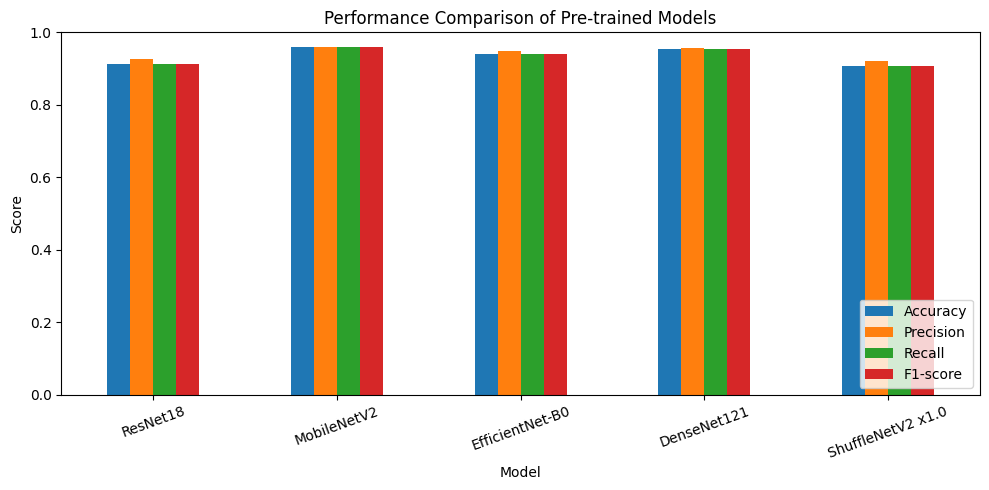

In [31]:
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]

results_df.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(10, 5),
    ylim=(0, 1)
)

plt.ylabel("Score")
plt.title("Performance Comparison of Pre-trained Models")
plt.xticks(rotation=20)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

### Interpretation of the Performance Comparison

The bar graph makes the differences among the five models easier to compare. **MobileNetV2 has the highest and most balanced values across accuracy, precision, recall, and F1-score**, with all four metrics reaching **0.9600**. DenseNet121 is only slightly lower, while EfficientNet-B0 ranks in the middle.

ResNet18 and ShuffleNetV2 have lower scores compared with the other models, although their values are still above 0.90. The small gaps between accuracy, precision, recall, and F1-score also suggest that the models performed fairly consistently across the three classes rather than performing well on only one class.

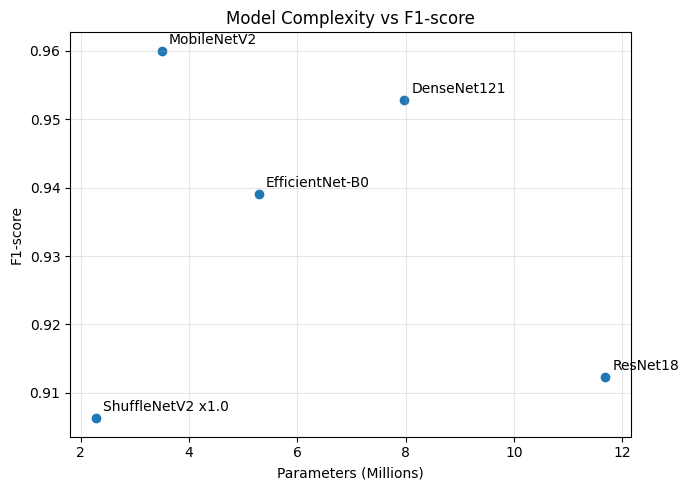

In [32]:
plt.figure(figsize=(7, 5))
plt.scatter(results_df["Parameters (M)"], results_df["F1-score"])

for _, row in results_df.iterrows():
    plt.annotate(
        row["Model"],
        (row["Parameters (M)"], row["F1-score"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("Parameters (Millions)")
plt.ylabel("F1-score")
plt.title("Model Complexity vs F1-score")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation of Model Complexity vs. F1-score

The scatter plot shows that having more parameters does not automatically result in better classification performance. **ResNet18 has the largest number of parameters at about 11.69 million, but its F1-score is only 0.9123.** In comparison, **MobileNetV2 uses only about 3.50 million parameters and still achieved the highest F1-score of 0.9600**.

ShuffleNetV2 is the smallest model with about 2.28 million parameters, but it also produced the lowest F1-score. This shows that model complexity alone does not determine performance. The architecture of the model and how well its pre-trained ImageNet features match the images in the selected dataset also affect the results.

## Analysis

Based on the results, the five pre-trained models were able to classify the Laptop, Mobile, and Supercar images with generally high performance even without additional training. Among the models, **MobileNetV2 performed the best**, reaching an accuracy, precision, recall, and F1-score of **0.9600**. DenseNet121 was a close second with an accuracy of **0.9533** and an F1-score of **0.9527**.

The results also show that a larger model does not always perform better. ResNet18 had the highest number of parameters among the five models, but it did not obtain the highest classification score. MobileNetV2 achieved better results while using much fewer parameters. This may be because the models use different architectures and learn visual features differently during their original ImageNet training.

The differences in performance may also be affected by the images themselves. The dataset contains different designs, angles, backgrounds, and appearances of laptops, mobile phones, and supercars. Some images may therefore be easier or harder for a pre-trained model to recognize. Since the dataset only contains **150 images and three classes**, the results are useful for comparing the models in this activity but may not represent their performance on a much larger or more diverse dataset.

## Conclusion

In this laboratory exercise, five ImageNet pre-trained models were successfully evaluated using a custom image classification dataset without performing additional training or fine-tuning. All models achieved an F1-score above 0.90, showing that their previously learned ImageNet features were suitable for recognizing the selected image classes.

For this dataset, **MobileNetV2 produced the strongest overall performance while also using relatively few parameters**. This shows that model selection should not be based only on model size. Classification performance, model architecture, computational requirements, and suitability for the dataset should all be considered when choosing a pre-trained model.